Reference Molecule:


[22:21:57] Initializing Normalizer


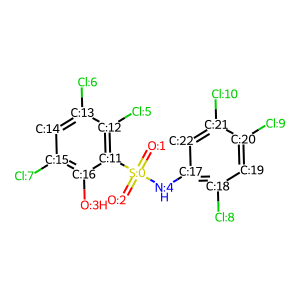

Fixed Fragment:


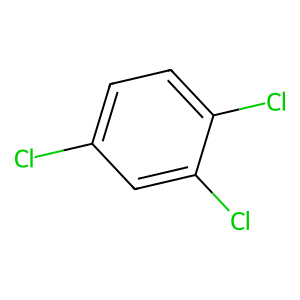

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import Draw

from src.mlconfgen.utils import get_context_shape
from src.mlconfgen.cheminformatics.pipeline import set_conformer_positions

import torch

def new_mol_from_atom_indices(mol: Chem.Mol, atom_indices) -> Chem.Mol:
    
    keep = sorted(set(int(i) for i in atom_indices))
    
    n = mol.GetNumAtoms()
    if keep[0] < 0 or keep[-1] > n:
        raise IndexError(f"atom index out of range (0..{n-1}): {keep}")

    keep_set = set(keep)

    # Map old atom idx -> new atom idx
    rw = Chem.RWMol()
    old2new = {}
    for old_i in keep:
        # Copy the atom object to preserve charge/isotope/aromaticity/etc.
        new_i = rw.AddAtom(Chem.Atom(mol.GetAtomWithIdx(old_i)))
        old2new[old_i] = new_i

    # Add bonds that connect kept atoms
    for b in mol.GetBonds():
        a, c = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        if a in keep_set and c in keep_set:
            rw.AddBond(old2new[a], old2new[c], b.GetBondType())
            nb = rw.GetBondBetweenAtoms(old2new[a], old2new[c])
            nb.SetIsAromatic(b.GetIsAromatic())

    out = rw.GetMol()

    # Copy coordinates for EACH conformer
    out.RemoveAllConformers()
    for conf in mol.GetConformers():
        new_conf = Chem.Conformer(len(keep))
        new_conf.Set3D(conf.Is3D())
        for old_i in keep:
            new_conf.SetAtomPosition(old2new[old_i], conf.GetAtomPosition(old_i))
        out.AddConformer(new_conf, assignId=True)

    return out

CONTEXT_NORMS = {
    'mean': torch.tensor([92.1179, 413.7875, 470.5253]),
    'mad': torch.tensor([53.4742, 232.5775, 251.1813]),
}

# Load a Reference conformer
ref_mol = Chem.MolFromMolFile('./assets/demo_files/yibfeu.mol')
# Load a Fragment, which you want generated molecules would have
# fixed_fragment = Chem.MolFromMolFile('./assets/demo_files/frag_yibfeu.mol')

# Align molecule First
ref_coord = torch.tensor(ref_mol.GetConformer().GetPositions())

# move coord to center
virtual_com = torch.mean(ref_coord, dim=0)
ref_coord = ref_coord - virtual_com

ref_context, aligned_coord = get_context_shape(ref_coord)

ref_mol = set_conformer_positions(ref_mol, aligned_coord)

fixed_fragment = new_mol_from_atom_indices(ref_mol,
                                            [8, 9, 10, 17, 18, 19, 20, 21, 22])

print("Reference Molecule:")
for a in ref_mol.GetAtoms():
        a.SetProp("molAtomMapNumber", str(a.GetIdx()))
    
display(Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(ref_mol)), includeAtomNumbers=True))

print("Fixed Fragment:")

display(Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(fixed_fragment))))

ref_block = Chem.MolToXYZBlock(ref_mol)
frag_block = Chem.MolToXYZBlock(fixed_fragment)

view = py3Dmol.view()
view.addModel(ref_block, "xyz")
view.setStyle(
            {"model": 0},
            {"stick": {"color": "magenta", "radius": 0.05}},
        )

view.addModel(frag_block, "xyz")


view.setStyle(
                {"model":1},
                {"stick": {"radius": 0.2}},
            )

view.show()


In [2]:
from src.mlconfgen.utils.mol_utils import (prepare_masks,
get_moment_of_inertia_tensor, shift_moi_to_com_batch,
prepare_adj_mat_seer_input, redefine_bonds)
from src.mlconfgen.utils.standardizer import standardize_mol

# Necessary functions


def ifm_prepare_gen_fragment_context(
    fixed_fragment_x: torch.Tensor,
    reference_context: torch.Tensor,
    context_norms: dict,
    n_nodes: torch.Tensor,
    max_n_nodes: int,
    min_n_nodes: int,
    device: torch.device,
):
    """
    Prepare Contexts for Generation of Individual Fragments based on Reference and Fixed Fragment MOI tensors.
    Fixed Fragment should be expressed in the same coordinate system as the reference, The origin of such coordinate
    system should be place in the COM of the Reference.

    :param fixed_fragment_x:  coordinates of the fixed fragment atoms
    :param reference_context: Principal components of MOI Tensor of the reference shape (3)
    :param context_norms: Values to norm the context for individual fragment generation
    :param n_nodes: a list of sizes of requested molecules (n_samples, 1)
    :param max_n_nodes: a maximal number of nodes allowed for the whole generated molecule
    :param min_n_nodes: a minimal number of nodes allowed for the whole generated molecule
    :param device: device to prepare input for - torch.device
    :return: frag_node_mask, frag_edge_mask, batched_normed_frag_context, shift, rotation
    """
    batch_size = n_nodes.size(0)
    ff_n_atoms = fixed_fragment_x.size(0)

    # Check that fragment size is adequate
    if ff_n_atoms >= min_n_nodes:
        raise ValueError(
            "Fragment must contain fewer atoms than minimum generation size."
        )
    if ff_n_atoms >= max_n_nodes:
        raise ValueError(
            "Fragment has more atoms than the maximum number of atoms requested."
        )

    masses_ff = torch.ones(ff_n_atoms, device=device)

    # Fixed fragment MOI around origin
    moi_ff = get_moment_of_inertia_tensor(fixed_fragment_x, masses_ff)  # (3, 3)

    # Reference MOI as diagonal matrix (expand to B)
    moi_ref = torch.diag(reference_context)  # (3, 3)

    moi_ref_batch = moi_ref.unsqueeze(0).repeat(batch_size, 1, 1)  # (B, 3, 3)
    moi_ff_batch = moi_ff.unsqueeze(0).repeat(batch_size, 1, 1)  # (B, 3, 3)

    # Gen frag MOI around origin
    moi_gen_origin = moi_ref_batch - moi_ff_batch  # (B, 3, 3)

    # COM of fixed fragment
    com_ff = fixed_fragment_x.mean(dim=0)  # (3,)

    gen_n_atoms = n_nodes.view(batch_size, 1).float() - ff_n_atoms  # (B, 1)

    # COM of generated fragments in respect to number of atoms in each
    shift = (ff_n_atoms * com_ff.view(1, 3)) / gen_n_atoms  # (B, 3)

    # Shift MOI to COM of generated fragment
    moi_gen_com = shift_moi_to_com_batch(
        moi_gen_origin, shift, gen_n_atoms
    )  # (B, 3, 3)

    # Diagonalize MOI of generated fragment
    frag_context, rotation = torch.linalg.eigh(moi_gen_com)  # (B, 3), (B, 3, 3)
    normed_frag_context = (
        (frag_context - context_norms["mean"]) / context_norms["mad"]
    ).to(device)

    max_n_nodes_frag = max_n_nodes - ff_n_atoms

    frag_node_mask, frag_edge_mask = prepare_masks(
        n_nodes=gen_n_atoms.long(),
        max_n_nodes=max_n_nodes_frag,
        device=device,
    )

    batched_normed_frag_context = (
        normed_frag_context.unsqueeze(1).repeat(1, max_n_nodes_frag, 1) * frag_node_mask
    )

    rotation = rotation.to(device)
    shift = shift.to(device)

    return frag_node_mask, frag_edge_mask, batched_normed_frag_context, shift, rotation


def predict_bonds(generator, edm_samples):
        (
            el_batch,
            dm_batch,
            b_adj_mat_batch,
            canonicalised_samples,
        ) = prepare_adj_mat_seer_input(
            mols=edm_samples,
            dimension=generator.dimension,
            device=generator.device,
        )

        adj_mat_batch = generator.adj_mat_seer(
            elements=el_batch, dist_mat=dm_batch, adj_mat=b_adj_mat_batch
        )

        adj_mat_batch = adj_mat_batch.to("cpu")

        # Append generated bonds and standardise existing samples
        optimised_conformers = []

        for i, adj_mat in enumerate(adj_mat_batch):
            f_mol = redefine_bonds(canonicalised_samples[i], adj_mat)
            std_mol = standardize_mol(mol=f_mol, optimize_geometry=True)
            if std_mol:
                optimised_conformers.append(std_mol)
            

        return optimised_conformers


import py3Dmol
from rdkit import Chem

from src.mlconfgen.utils import inverse_coord_transform

def show_overlay_grid(
    reference_mol,
    candidate_mols,
    n_cols=3,
    width=300,
    height=300,
):

    def mol_to_block(mol):
        return Chem.MolToXYZBlock(mol)

    n_rows = (len(candidate_mols) + n_cols - 1) // n_cols

    view = py3Dmol.view(
        viewergrid=(n_rows, n_cols),
        width=width * n_cols,
        height=height * n_rows,
    )

    ref_block = mol_to_block(reference_mol)

    for i, cand in enumerate(candidate_mols):
        r = i // n_cols
        c = i % n_cols


        # Add reference (magenta)
        view.addModel(ref_block, "xyz", viewer=(r, c))
        view.setStyle(
            {"model": 0},
            {"stick": {"color": "magenta", "radius": 0.05}},
            viewer=(r, c),
        )

        # Add candidates
        cand_block = mol_to_block(cand)
        view.addModel(cand_block, "xyz", viewer=(r, c))
        view.setStyle(
                {"model":1},
                {"stick": {"radius": 0.2}},
                viewer=(r, c),
            )
        view.addSphere({
                        "center": {"x": 0, "y": 0, "z": 0},
                        "radius": 0.3,      # tweak size
                        "color": "red",
                        "opacity": 1.0
                    })

        view.zoomTo(viewer=(r, c))

    view.show()
    return None

def show_overlay_grid_animated(
    reference_mol,
    candidate_mols_ll,   # list[list[Mol]]  (frames per cell)
    n_cols=3,
    width=300,
    height=300,
    interval=80,         # ms per frame
    loop="forward",      # "forward", "backward", "backAndForth"
):
    def mols_to_xyz_frames(mols):
        # xyz "trajectory": concatenate multiple XYZ blocks
        # py3Dmol's xyz reader can treat concatenated XYZ as frames via addModelsAsFrames
        return "".join(Chem.MolToXYZBlock(m) for m in mols)

    n_cells = len(candidate_mols_ll)
    n_rows = (n_cells + n_cols - 1) // n_cols

    view = py3Dmol.view(
        viewergrid=(n_rows, n_cols),
        width=width * n_cols,
        height=height * n_rows,
    )

    ref_block = Chem.MolToXYZBlock(reference_mol)

    for i, frames in enumerate(candidate_mols_ll):
        r, c = divmod(i, n_cols)

        # --- Reference (static) as model 0
        view.addModel(ref_block, "xyz", viewer=(r, c))
        view.setStyle(
            {"model": 0},
            {"stick": {"color": "magenta", "radius": 0.05}},
            viewer=(r, c),
        )

        # --- Candidates (animated frames) as model 1
        if frames is None or len(frames) == 0:
            continue

        frames_xyz = mols_to_xyz_frames(frames)
        view.addModelsAsFrames(frames_xyz, "xyz", viewer=(r, c))
        view.setStyle(
            {"model": 1},
            {"stick": {"radius": 0.2}},
            viewer=(r, c),
        )

        # Red dot at origin (per cell)
        view.addSphere(
            {
                "center": {"x": 0, "y": 0, "z": 0},
                "radius": 0.3,
                "color": "red",
                "opacity": 1.0,
            },
            viewer=(r, c),
        )

        view.zoomTo(viewer=(r, c))

    # Animate all viewers
    view.animate({"loop": loop, "interval": interval})
    view.show()
    return None

tensor([[23],
        [23],
        [23],
        [23],
        [23],
        [23],
        [23],
        [23],
        [23],
        [23]], device='mps:0')
Intitialising model on mps:0
Generating Fragments...
X Size: torch.Size([10, 14, 3])
H Size: torch.Size([10, 14, 8])


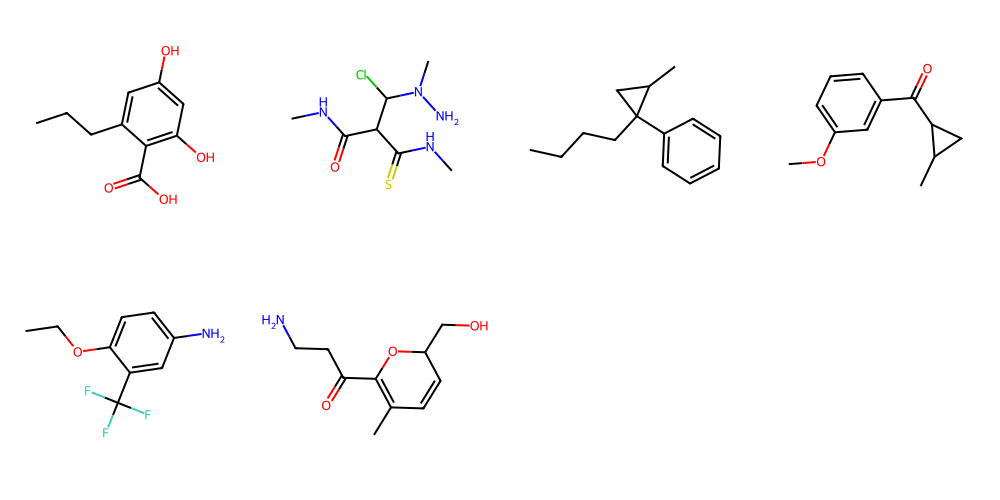

In [3]:
from src.mlconfgen.utils import get_context_shape, prepare_edm_input, samples_to_rdkit_mol
from src.mlconfgen import MLConformerGenerator
from src.mlconfgen.cheminformatics.pipeline import set_conformer_positions
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')



N_SAMPLES = 10
VARIANCE = 0
RESAMPLE_STEPS=0

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps:0")
else:
    device = torch.device("cpu")


n_nodes = ref_coord.size(0)
min_n_nodes = n_nodes - VARIANCE
max_n_nodes = n_nodes + VARIANCE

ff_coord = torch.tensor(fixed_fragment.GetConformer().GetPositions(), dtype=torch.float32).to(device)

node_mask, edge_mask, batch_context = prepare_edm_input(
            n_samples=N_SAMPLES,
            reference_context=ref_context,
            context_norms=CONTEXT_NORMS,
            min_n_nodes=min_n_nodes,
            max_n_nodes=max_n_nodes,
            device=device,
        )

n_nodes_2 = torch.sum(node_mask, dim=1).to(torch.long)

print(n_nodes_2)


# Preparing the Gen Fragment Context
(frag_node_mask,
 frag_edge_mask,
 batched_normed_frag_context,
 shift,
 rotation) = ifm_prepare_gen_fragment_context(
    fixed_fragment_x=ff_coord,
    reference_context=ref_context,
    context_norms=CONTEXT_NORMS,
    n_nodes=n_nodes_2,
    max_n_nodes=max_n_nodes,
    min_n_nodes=min_n_nodes,
    device=device,
) 

print(f"Intitialising model on {device}")
    
generator = MLConformerGenerator(
                                 edm_weights="./licensed_edm_moi_chembl_6_39_final.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=100, # Light generation for debugging
                                )

print("Generating Fragments...")
with torch.no_grad():
    total_x, total_h = generator.generative_model(
                                                    frag_node_mask,
                                                    frag_edge_mask,
                                                    batched_normed_frag_context,
                                                    resample_steps=RESAMPLE_STEPS,
                                                 )

gen_mols = samples_to_rdkit_mol(
            positions=total_x, one_hot=total_h, node_mask=frag_node_mask, atom_decoder=generator.atom_decoder
        )

print(f"X Size: {total_x.size()}")
print(f"H Size: {total_h.size()}")

temp_mols = predict_bonds(generator, gen_mols)
temp_mols = [Chem.MolFromSmiles(Chem.MolToSmiles(x)) for x in temp_mols]
img = Draw.MolsToGridImage(
        temp_mols,
        molsPerRow=4,
        subImgSize=(250, 250),
    )

display(img)

In [4]:
import py3Dmol
from rdkit import Chem

from src.mlconfgen.utils import inverse_coord_transform


aligned_x = []
for frag_coord in total_x:
    
    _, a_coord = get_context_shape(frag_coord.to("cpu")) 
    aligned_x.append(a_coord)

aligned_x = torch.stack(aligned_x, dim=0)
    
new_x = inverse_coord_transform(coord=aligned_x.to("cpu"),
                                shift=shift.to("cpu"),
                                rotation=rotation.to("cpu"),
                                )

# new_x = inverse_coord_transform(coord=total_x.to("cpu"),
#                                 shift=shift.to("cpu"),
#                                 rotation=rotation.to("cpu"),
#                                 )


    
# Visually check inverse transform

inv_tr_frag_mols = samples_to_rdkit_mol(
            positions=new_x, one_hot=total_h, node_mask=frag_node_mask, atom_decoder=generator.atom_decoder
        )




show_overlay_grid(ref_mol, inv_tr_frag_mols)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
from src.mlconfgen.utils import ifm_get_xh_from_fragment, ifm_prepare_fragments_for_merge

fixed_fragment_x, fixed_fragment_h = ifm_get_xh_from_fragment(
                    fixed_fragment=fixed_fragment, device=device
                )

z_known, fixed_mask = ifm_prepare_fragments_for_merge(
                    fixed_fragment_x=fixed_fragment_x,
                    fixed_fragment_h=fixed_fragment_h,
                    gen_fragments_x=new_x.to(device),
                    gen_fragments_h=total_h,
                    device=device,
                    max_n_nodes=max_n_nodes,
                )

prepared_x = z_known[:,:,:3]
prepared_h = z_known[:,:,3:]

# Prepared fragments

tmp_prep_frags = samples_to_rdkit_mol(
            positions=prepared_x, one_hot=prepared_h, node_mask=node_mask, atom_decoder=generator.atom_decoder
        )

print(prepared_x.size())




show_overlay_grid(ref_mol, tmp_prep_frags)



torch.Size([10, 23, 3])


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Merging fragments...


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders



AVERAGE SHAPE SIMILARITY - 0.49833333333333335
VALID SAMPLES - 60.0 %


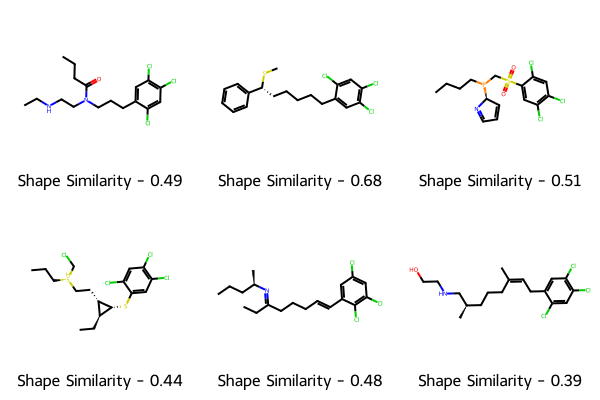

In [18]:
from src.mlconfgen import evaluate_samples
from src.mlconfgen.inertial_fragment_matching import predict_bonds_openbabel

print("Merging fragments...")

merger = MLConformerGenerator(
                                 edm_weights="./edm_moi_chembl_15_39.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=100, # Light generation for debugging
                                )

with torch.no_grad():
    final_x, final_h = merger.generative_model.merge_fragments_with_injection(
        node_mask,
        edge_mask,
        fixed_mask,
        context=batch_context,
        z_seed=z_known,
        diffusion_level=50,
        resample_steps=0,
        blend_power=3,
    )

final_mols = samples_to_rdkit_mol(
            positions=final_x, one_hot=final_h, node_mask=node_mask, atom_decoder=generator.atom_decoder
        )

obabel_mols = []

# Switched to deterministic bond prediction
for mol in final_mols:
    f_mol = predict_bonds_openbabel(mol, optimize_geometry=False)
    if f_mol:
        obabel_mols.append(f_mol)

_, std_samples = evaluate_samples(ref_mol, obabel_mols)

# Display results
mols = []
legends = []
average_shape_similarity = 0
for sample in std_samples:
    mol = Chem.MolFromMolBlock(sample['mol_block'])
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol))
    mol.SetProp("Shape_Tanimoto", str(sample['shape_tanimoto']))
    mols.append(mol)
    legends.append(f"Shape Similarity - {round(sample['shape_tanimoto'], 2)}")
    average_shape_similarity += round(sample['shape_tanimoto'], 2)

average_shape_similarity = average_shape_similarity / len(std_samples)
print(f"AVERAGE SHAPE SIMILARITY - {average_shape_similarity}")
print(f"VALID SAMPLES - {round(len(std_samples) / N_SAMPLES, 2) * 100} %")
    
Draw.MolsToGridImage(mols, legends=legends)

    